In [1]:
# Cell 0 -- Environment setup
# Colab:  clones the repo (code + data) into the temporary VM.
# Kaggle: uses the attached dataset if present; falls back to GitHub clone.
# Local:  no-op.
import os, sys

def _in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

def _in_kaggle():
    return os.path.exists('/kaggle/working')

GITHUB_URL = 'https://github.com/deijany/CNN_linearizer.git'

if _in_kaggle():
    kaggle_dataset = '/kaggle/input/datasets/deijany/freq-depend-ord2-grade10'
    if os.path.exists(kaggle_dataset):
        # Dataset attached via Kaggle UI -- use it directly
        if kaggle_dataset not in sys.path:
            sys.path.insert(0, kaggle_dataset)
        os.chdir('/kaggle/working')
        if not os.path.exists('/kaggle/working/datasets'):
            os.symlink(f'{kaggle_dataset}/datasets', '/kaggle/working/datasets')
        print('[Kaggle] Ready (dataset attached) -- working directory:', os.getcwd())
    else:
        # Dataset not attached -- clone from GitHub into /kaggle/working
        repo_dir = '/kaggle/working/CNN_linearizer'
        if not os.path.exists(repo_dir):
            os.system('git clone ' + GITHUB_URL + ' ' + repo_dir)
        os.chdir(repo_dir)
        if repo_dir not in sys.path:
            sys.path.insert(0, repo_dir)
        print('[Kaggle+GitHub] Ready -- working directory:', os.getcwd())

elif _in_colab():
    repo_dir = '/content/CNN_linearizer'
    if not os.path.exists(repo_dir):
        os.system('git clone ' + GITHUB_URL + ' ' + repo_dir)
    os.chdir(repo_dir)
    if repo_dir not in sys.path:
        sys.path.insert(0, repo_dir)
    print('[Colab] Ready -- working directory:', os.getcwd())

else:
    print('[Local] No setup needed -- working directory:', os.getcwd())


Cloning into '/kaggle/working/CNN_linearizer'...


[Kaggle+GitHub] Ready -- working directory: /kaggle/working/CNN_linearizer


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/deijany/CNN_linearizer/blob/main/main_nnlinearizer.ipynb)  [![Open In Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/deijany/CNN_linearizer/blob/main/main_nnlinearizer.ipynb)

# CNN-Based ADC Linearizer

This notebook implements a **CNN-based linearizer** for ADC "frequency dependent" nonlinearity correction.
It was developed in 2022 during my PhD as an early exploration of gradient-based training for this problem.

The target application is **real-time signal processing**, where hardware complexity is a hard constraint.
Increasing the number of layers, neurons, or connections directly translates into higher latency and power consumption on FPGAs or ASICs -- making standard deep neural network design choices a drawback here.
This motivated looking for architectures that achieve good performance with minimal, structured parameters.

While working on this, we realized that a significantly better approach exists:
decomposing the optimization into a **set of subconvex problems**, each solvable analytically by matrix inversion (no gradient descent required).
That approach converges faster, is more interpretable, and achieves higher signal-to-noise and distortion ratio (SNDR).
It was published in 2025.

> **Low-Complexity Frequency-Dependent Linearizers Based on Parallel Bias-Modulus and Bias-ReLU Operations**  
> IEEE Access (open access) · [ieeexplore.ieee.org/document/11293818](https://ieeexplore.ieee.org/document/11293818)  arXiv · [arxiv.org/abs/2412.16210](https://arxiv.org/abs/2412.16210)

The files `proposed_linearizer_in_IEEA_access2025.py` and `hammerstein_linearizer.py` in this repository are the code from that paper.
This notebook documents the CNN path -- including the lessons learned along the way.

---

### A note on the nonlinearity model

The paper considers two cases depending on where the nonlinearity occurs:

I- **Digital-domain model** -- the nonlinearity acts on the already-sampled signal. Distortion products remain within the Nyquist band, so the linearizer can operate directly at the sampling rate. This is the case implemented in this project.

II- **Analog-domain model** -- the nonlinearity acts on the analog waveform before sampling. Harmonics and intermodulation products are not bandlimited and extend beyond the signal band; a proper linearizer then requires interpolation, processing at a higher rate, and downsampling at the output. This case is covered in the paper but not included in this sample project.

In [2]:
# Imports
from myclasses.file_manipulation import PathManager, DataSetLoader
from myclasses.env_utils         import get_cpu_info, is_colab
from myclasses.system_check      import SystemCheck
from myclasses.callbacks         import UniversalPrintCallback
from myfunctions.functions_helper import (
    SpectrumAnalyzer, compute_statistics,
    storate_dictionary, load_dictionary,
)

import numpy as np

# suppress C++ plugin-registration noise 
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
_devnull = open(os.devnull, 'w'); _old_fd = os.dup(2); os.dup2(_devnull.fileno(), 2)
import tensorflow as tf
os.dup2(_old_fd, 2); os.close(_old_fd); _devnull.close()

tf.get_logger().setLevel('ERROR')   # suppress tf.function retracing warnings 
if tf.test.is_built_with_cuda():
    tf.config.optimizer.set_jit(True)

layers = tf.keras.layers
models = tf.keras.models

# System check
SystemCheck().print_summary()

2026-05-29 20:10:57.690485: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780085458.110915      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780085458.228094      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780085459.208562      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780085459.208616      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780085459.208622      58 computation_placer.cc:177] computation placer alr

------------------------------------------------------------------------------------
tensorflow_version=2.19.0
------------------------------------------------------------------------------------
A GPU is connected:
  GPU 0: Tesla T4  |  15360 MiB  |  38C
  GPU 1: Tesla T4  |  15360 MiB  |  39C
No TPU connected.
CPU Info:
CPU(s):                                  4
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
Thread(s) per core:                      2
Core(s) per socket:                      2
You are using a high-RAM runtime!
RAM: 29.9 GiB available / 31.4 GiB total
------------------------------------------------------------------------------------


In [3]:
# =================================================================
# Configuration -- only edit here
# =================================================================
ACTIVATION        = 'abs'        # 'relu' | 'abs' | 'pow'
BRANCH_NUMBER     = 8            # nonlinear branches in the CNN model
LINEARIZER_ORDER  = 2            # Conv1D kernel_size = LINEARIZER_ORDER + 1
CAUSAL_SYSTEM = False  # True: delays passthrough by LINEARIZER_ORDER//2 samples,
                       #       matching the group delay of a linear-phase (symmetric) FIR.
                       #       Implicitly biases the network toward symmetric coefficients.
                       #       False: passthrough is V[n] directly.

BIAS_RANGE        = (-1.0, 1.0)  # (min, max) initial span of the ordered bias grid
SAVE_RESULTS      = False        
PLOTTING          = True         

# Training quick demo defaults (Adam + BFGS fine-tuning):
# 20 epochs x 20 restarts -> Start ~ 30dB, Adam ~36 dB, after BFGS ~54 dB SNDR.
# Adam alone (no BFGS) needs NO_EPOCHS > 3000 and NUM_RESTARTS > 500 and learning rate decay to match that,
# which takes a long time to run.

NO_EPOCHS         = 20     
BATCH_SIZE        = 4
VALIDATION_SPLIT  = 0.05
NUM_RESTARTS      = 20           
LEARNING_RATE     = 0.01

# Statistics
DATA_BITS         = 12
EST_BITS          = 14

### Dataset

Each signal pair `(X, V)` consists of a clean multisine signal `X` and its distorted version `V`, where the distortion follows a frequency-dependent Hammerstein model: a linear FIR branch plus $P-1$ nonlinear branches, each being a polynomial nonlinearity of degree $p$ followed by a FIR filter of order $K$:

$$V[n] = \sum_{k=0}^{K} c_1[k] \cdot x[n-k] + \sum_{p=2}^{P} \sum_{k=0}^{K} c_p[k] \cdot x^p[n-k]$$

where the first term is the linear branch (convolution of $x$ with FIR taps $c_1[k]$), and the second term covers $P-1$ nonlinear branches with polynomial degrees $p = 2, \ldots, P$, each convolved with FIR taps $c_p[k]$. For this dataset: $K=2$ (3-tap filters), $P=10$ (polynomial degrees 2 to 10). The coefficients $c_p[k]$ are stored in `datasets/nonlinear_coeff.h5` (and `.txt`) alongside the signal files.

The dataset included in this repository contains **50 training signals and 50 test signals** (8192 samples each, 12-bit quantization, distortion order 2, 9 nonlinear terms). This is a reduced sample kept for space constraints -- in practice, training with several hundred signals produces more stable results and better generalisation across different input conditions.

In [4]:
# Dataset parameters (must match the folder in datasets/)
ACTIVE_CARRIERS   = 31  # number of active carriers in the multi-tone signal
DISTORTION_ORDER  = 2   # order of the frequency-dependent distortion
DISTORTION_BRANCHES = 9 # number of nonlinear branches in the distortion model x^2, x^3, ..., x^10

# =================================================================
# Load Data
# =================================================================
dataset_version = 210000 + 100*int(ACTIVE_CARRIERS) + 10*int(DISTORTION_ORDER) + int(DISTORTION_BRANCHES)
folder_prefix   = 'v' + str(dataset_version)

current_path, _ = PathManager().check_path_by_host()
train_path, test_path = PathManager().load_path(
    root_path=current_path, local_path='datasets',
    folder_prefix=folder_prefix, state='data'
)
simulation_path = PathManager().make_path(
    root_path=current_path, local_path='trained_model',
    current_path=folder_prefix, state='simulations'
)

loader_train = DataSetLoader(path=train_path, num_files=50)
data_train   = loader_train.load_dataset()
X      = data_train['pure_signal']
V      = data_train['distorted_signal']

loader_test = DataSetLoader(path=test_path, num_files=50)
data_test   = loader_test.load_dataset()
X_test = data_test['pure_signal']
V_test = data_test['distorted_signal']

matching_folders: ['v213129_fdep_2ord_10terms_12bits']
simulations_path: ./trained_model/v213129
Loaded 50 files — shape: (50, 8192)
Loaded 50 files — shape: (50, 8192)


## Lessons Learned

The following design choices were not obvious at the start. They are documented here because each one has a real impact on whether the model is useful or if it converges at all.

---

### 1. No cross-connections between branches

Standard neural networks connect every neuron to every other neuron in the next layer. For this problem that is counterproductive. Each nonlinear branch is meant to capture a specific mode of the distortion independently. Cross-connections introduce redundant parameters, complicate training, and increase hardware cost. The architecture used here keeps branches strictly parallel: each branch processes the input independently and the outputs are summed at the end.

---

### 2. Branches must not collapse during optimization

Because all nonlinear branches have the same structure, unconstrained optimization tends to make them converge to the same solution or oscillate between similar states. To prevent this, the bias applied before each activation is constrained so that

$$b_1 < b_2 < \cdots < b_N$$

This is implemented as a cumulative sum of independent positive increments (OrderedBiasLayer), so the constraint is automatically satisfied at every gradient step without projection or penalty terms. It enforces diversity between branches while keeping the optimization landscape smooth.

---

### 3. One linear branch plus nonlinear branches

ADC nonlinearity is weak: the dominant distortion in real systems is linear (gain and phase errors) with a small nonlinear component on top. The linearizer should reflect this:

- One linear FIR branch to correct linear distortion (and any linear frequency dependence).
- $N$ nonlinear branches, each of the form: $\text{activation}(V[n] + b_m) \rightarrow \text{FIR filter}$.

Treating all branches as nonlinear wastes capacity on something the linear branch handles exactly. Adding the linear branch also makes the model more interpretable: at the end of training you can inspect whether the correction is mostly linear or nonlinear.

---

### 4. Initialization scale must match the correction signal

The neural network model (linearizer) output is structured as

$$\hat{X}[n] = V[n] + \sum_{m=1}^{N} \sum_{k=0}^{K} h_m[k] \cdot \phi_m\bigl(V[n-k] + b_m\bigr) + \sum_{k=0}^{K} c_0[k] \cdot V[n-k] + b_0$$

so at initialization, if all branch kernels are zero, X_hat = V exactly. The loss at that point equals |X - V|, which for this dataset has RMS around 0.011.

If the branch kernels are initialized with a standard scheme such as GlorotUniform or HeNormal, they produce outputs with norm close to 1, roughly 77 times larger than the actual correction. The optimizer then spends all its capacity just recovering from the bad start rather than learning the correction. In this experiment that produced SNDR worse than the uncorrected signal.

The fix is straightforward: initialize all branch kernels to zero. The gradient is still nonzero because the activations and the biases are nonzero, so learning begins immediately at the right scale.

---
### Model Architecture
---
*Architecture diagram (N=3 nonlinear branches shown for clarity; default config uses N=8):*

The diagram shows:

- (1) **passthrough** -- V[n] fed directly, no learnable parameters
- (2) **linear bypass** (`c0`) -- learnable FIR filter that corrects linear distortion
- (3) **N nonlinear branches** -- each applies an ordered bias, a nonlinear activation, and a learnable FIR filter; the ordered constraint keeps branches from collapsing to the same solution (or jump around) during optimization (cf., point 2. in Lessons Learned)

![CNN Linearizer Architecture](https://raw.githubusercontent.com/deijany/CNN_linearizer/main/model_3nonlinear_branches.png)

> **Note:** the passthrough (1) has no trainable parameters and can be absorbed by the linear bypass (2); keeping it separate forces the bypass to learn only the residual correction, which is an easier optimization problem. In hardware implementation these two branches would be merged.

---

**Trainable parameters (default: N=8, K=2):**

| Component | Count |
|-----------|-------|
| N ordered bias increments | 8 |
| N x (K+1) nonlinear branch taps (8x3) | 24 |
| 1 x (K+1) linear bypass taps  (1x3) | 3 |
| Output DC offset (CustomAdd) | 1 |
| **Total** | **36** |

36 parameters is 3-4 orders of magnitude smaller than a standard MLP for the same task.
Each branch maps to a hardware multiply-accumulate (MAC) unit, making real-time FPGA/ASIC
deployment straightforward.

In [5]:
class CustomAdd(layers.Layer):
    """Learnable-bias sum of all branch outputs."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.c0 = self.add_weight(
            name='c0', shape=(input_shape[0][-1],),
            initializer='zeros', trainable=True
        )

    def call(self, inputs):
        return tf.add_n(inputs) + self.c0


class OrderedBiasLayer(layers.Layer):
    """Cumulative bias chain: bias[k] = b1 + b2 + ... + b(k+1).
    Each bk is an independent trainable scalar.

    Initialization: evenly-spaced grid from lo to hi, then the entire grid
    is shifted by a single random offset in [0, spacing]. This gives a
    different starting position each restart (initialization) while guaranteeing bias[k] < bias[k+1]
    always holds -- no swapping possible.

    Set np.random.seed() before define_block() to get a different shift per restart.
    """
    def __init__(self, n_branches: int, init_range: tuple = (-1.0, 1.0), **kwargs):
        super().__init__(**kwargs)
        self.n_branches = n_branches
        self.init_range = init_range

    def build(self, input_shape):
        lo, hi  = self.init_range
        spacing = (hi - lo) / max(self.n_branches - 1, 1)
        shift   = np.random.uniform(0, spacing)   # same shift for all -> no swapping
        init_vals = [lo + shift] + [spacing] * (self.n_branches - 1)
        self._bk = [
            self.add_weight(name=f'b{k+1}', shape=(1,),
                            initializer=tf.keras.initializers.Constant(init_vals[k]),
                            trainable=True)
            for k in range(self.n_branches)
        ]

    def call(self, inputs):
        results = []
        cumval = tf.zeros_like(self._bk[0])   # matches weight dtype/device; avoids reshape issues in Keras 3
        for k in range(self.n_branches):
            cumval = cumval + self._bk[k]
            results.append(inputs + cumval)    # (1,) broadcasts to match inputs shape
        return results


# Causal delay helper
def _delay_input(x, delay: int):
    if delay == 0:
        return x
    x = layers.ZeroPadding1D(padding=(delay, 0), name='delay_pad')(x)
    x = layers.Cropping1D(cropping=(0, delay),   name='delay_crop')(x)
    return x


# Activation helper
def _make_activation(i: int, activation: str, x):
    if activation == 'relu':
        return layers.ReLU(name=f'actv{i+1}')(x)
    elif activation == 'abs':
        return layers.Lambda(lambda t: tf.abs(t), name=f'actv{i+1}')(x)
    elif activation == 'pow':
        # Hammerstein model with polynomial nonlinearity: branch i -> degree i+2 (x^2, x^3, ...)
        return layers.Lambda(lambda t, p=i+2: tf.pow(t, p), name=f'actv{i+1}')(x)
    else:
        raise ValueError(f"Unknown activation '{activation}'. Choose 'relu', 'abs', or 'pow'.")


def define_block(input_shape, branches, linearizer_order, k_initializer,
                 outputs=1, activation: str = ACTIVATION, causal: bool = CAUSAL_SYSTEM,
                 bias_range: tuple = (-1.0, 1.0)):
    """Build the CNN linearizer model.

    Branch Conv1D kernels start at zero (correct scale for the small correction signal).
    Bias grid shifts randomly by [0, spacing] each call. 
    """
    delay       = linearizer_order // 2 if causal else 0
    inp         = layers.Input(shape=input_shape, name='input')
    passthrough = _delay_input(inp, delay)
    bypass      = layers.Conv1D(filters=1, kernel_size=linearizer_order + 1, use_bias=False,
                                padding='same', activation=None,
                                kernel_initializer='zeros', name='c0')(inp)

    biased = OrderedBiasLayer(n_branches=branches, init_range=bias_range,
                              name='ordered_bias')(inp)

    paths = [passthrough]
    for i in range(branches):
        x = _make_activation(i, activation, biased[i])
        x = layers.Conv1D(filters=1, kernel_size=linearizer_order + 1, use_bias=False,
                          padding='same', activation=None,
                          kernel_initializer=k_initializer, name=f'conv{i+1}')(x)
        paths.append(x)

    paths.append(bypass)
    out = CustomAdd(name='output')(paths)
    return models.Model(inputs=inp, outputs=out, name='CNN_Linearizer')

I0000 00:00:1780085482.279556      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780085482.285627      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "CNN_Linearizer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 8192, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ordered_bias        │ [(None, 8192, 1), │          8 │ input[0][0]       │
│ (OrderedBiasLayer)  │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1),  │            │                   │
│                     │ (None, 8192, 1)]  │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv1 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv2 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv3 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv4 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv5 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv6 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv7 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ actv8 (Lambda)      │ (None, 8192, 1)   │          0 │ ordered_bias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv5 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv6 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv7 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv8 (Conv1D)      │ (None, 8192, 1)   │          3 │ actv8[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c0 (Conv1D)         │ (None, 8192, 1)   │          3 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (CustomAdd)  │ (None, 8192, 1)   │          1 │ input[0][0],      │
│                     │                   │            │ conv1[0][0],      │
│                     │                   │            │ conv2[0][0],      │
│                     │                   │            │ conv3[0][0],    

 Total params: 36 (144.00 B)

 Trainable params: 36 (144.00 B)

 Non-trainable params: 0 (0.00 B)

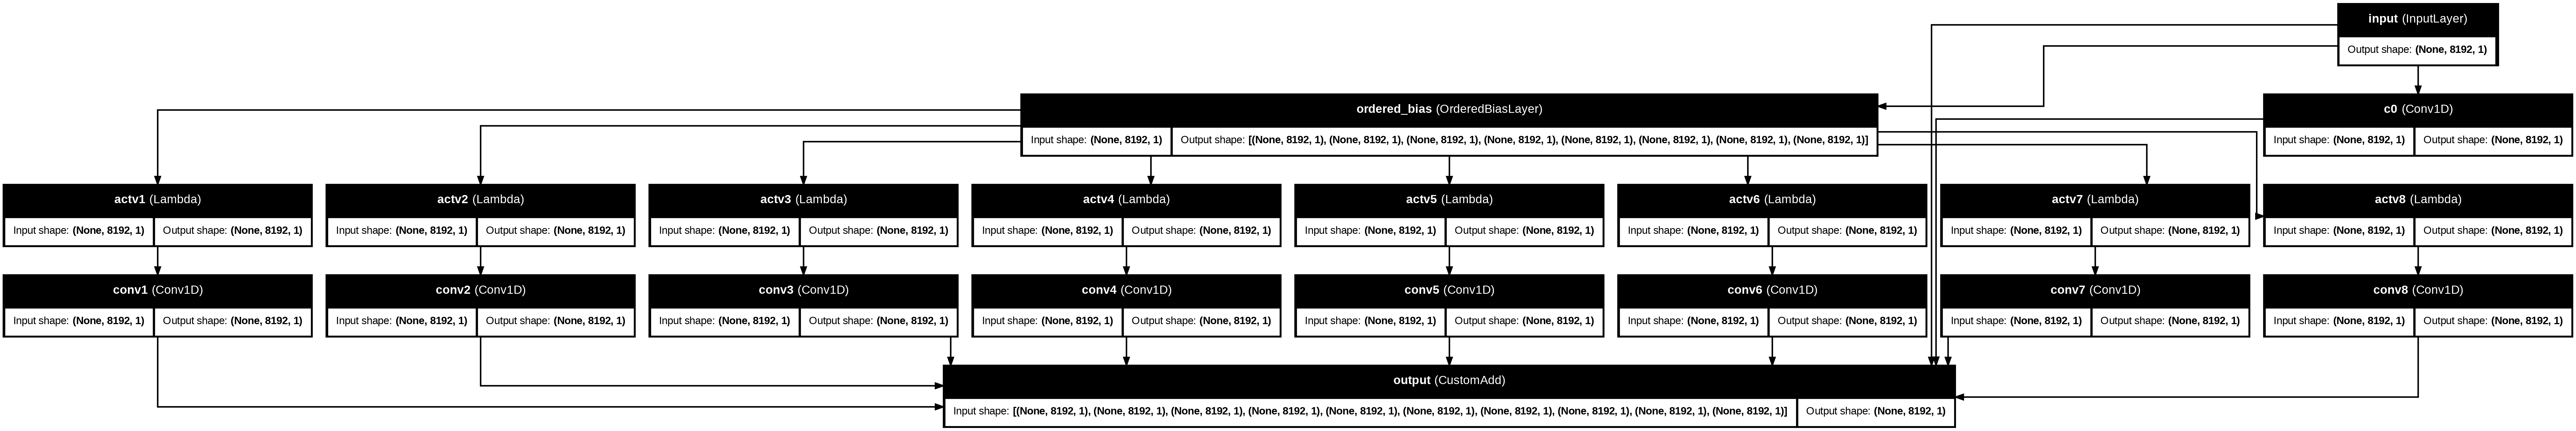

In [6]:
# =================================================================
# Build model
# =================================================================
input_shape = (len(V_test[0]), 1)
# Zeros init: all branch kernels start at 0  model output ~ V at t=0
# (X-V correction has RMS ~0.01; GlorotUniform/HeNormal give norms ~1 -> 77x off)
initializer = tf.keras.initializers.Zeros()

neural_network_model = define_block(
    input_shape, BRANCH_NUMBER, LINEARIZER_ORDER,
    k_initializer=initializer, outputs=1, bias_range=BIAS_RANGE
)
neural_network_model.summary()
tf.keras.utils.plot_model(neural_network_model, show_shapes=True, show_layer_names=True)


In [7]:
# =================================================================
# Training setup
# =================================================================
loss    = tf.keras.losses.MeanSquaredError(reduction='sum_over_batch_size', name='mse')
metrics = [tf.keras.metrics.MeanAbsolutePercentageError(name='mape')]

universal_print_callback = UniversalPrintCallback()

## Training Strategy: Adam from Different Initialization Points + BFGS Fine-tuning

Training uses two complementary optimizers in sequence.

**Stage 1 -- Adam (stochastic, first-order)**  
Adam runs `NUM_RESTARTS` independent training runs from different initialization points.
Each run samples a different bias grid position via `OrderedBiasLayer`, providing diverse
starting points for the nonconvex optimization problem. With a small epoch budget per run,
the goal is basin (valleys) discovery, not convergence.

**Stage 2 -- BFGS (deterministic, quasi-Newton)**  
BFGS runs on the full training set and approximates the Hessian to take
second-order information-aware steps. It is applied to *every* Adam restart independently and the
globally best result is kept. For ~36 parameters, each BFGS call converges in
seconds -- the second-order approximation is cheap at this scale.

**Why both?**  
Adam alone needs >2000 epochs per restart to reach the same precision that BFGS
reaches in ~100 iterations. BFGS alone is sensitive to initialization -- it converges
to whatever basin it starts in. The two stages complement each other: Adam provides
diverse starting points, BFGS extracts the best solution from each one.

**Why no L-BFGS?**  
L-BFGS saves memory by approximating the Hessian using only the last `m` gradient vectors instead of the full history. For 36 parameters, the full 36x36 Hessian is trivially cheap to store and invert -- full BFGS uses all available second-order information and converges more accurately at this scale.

---
### Device Selection: Why Each Stage Runs Where It Does

The two stages have fundamentally different compute patterns -- which is why they use different devices.

**Stage 1 -- Adam on GPU when available**

Each restart is an independent training run: forward pass, backward pass, weight update,
repeated for `NO_EPOCHS` epochs. This is compute-dense and maps well to GPU execution.
When multiple GPUs are present the restarts are distributed round-robin, one per GPU slot.
All restarts run in parallel via `ThreadPoolExecutor` regardless of platform.

On macOS with Metal, TF routes all ops through a single command queue regardless of how
many GPU cores the chip has -- concurrent threads serialise at the GPU level. The M-series
performance cores run truly in parallel, so CPU threads are faster on Apple Silicon.

**Stage 2 -- BFGS always on CPU, on every platform**

`scipy.minimize` calls the objective function hundreds of times per restart
(~100 iterations x ~15 line-search steps ~ 1500 calls). Each call does:

```
Python -> unpack weights -> TF forward+backward -> .numpy() -> Python
```

That is two GPU sync roundtrips per call (~1 ms each). Across all restarts:

```
NUM_RESTARTS x 1500 calls x 2 syncs x 1 ms ~ tens of seconds in sync overhead alone
```

The actual math -- 36 parameters over 8192 samples -- takes microseconds on CPU.
Sync overhead dominates completely. CPU eliminates it entirely.
BFGS restarts also run fully in parallel via `ThreadPoolExecutor` (one thread per restart, capped at core count).

| Stage | CUDA available | macOS Metal | No GPU |
|-------|----------------|-------------|--------|
| **Adam** | Parallel across N GPUs (round-robin) | Parallel CPU threads | Parallel CPU threads |
| **BFGS** | Parallel CPU threads | Parallel CPU threads | Parallel CPU threads |

In [8]:
# =================================================================
# Train -- NUM_RESTARTS Adam restarts
# CUDA:  parallel via ThreadPoolExecutor, restarts round-robin across GPUs.
# Metal (Apple Silicon): parallel CPU threads -- Metal driver serialises
#   GPU ops internally; M-series performance cores give real concurrency.
# CPU-only: parallel CPU threads.
# Saves every restart for BFGS stage; evaluates best Adam result.
# =================================================================
import os, platform, threading
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

def _use_cuda():
    return tf.test.is_built_with_cuda() and bool(tf.config.list_physical_devices('GPU'))

_IS_CUDA  = _use_cuda()
_IS_METAL = platform.system() == 'Darwin' and bool(tf.config.list_physical_devices('GPU'))

# Always parallel; CUDA pins restarts to GPU slots, Metal/CPU uses CPU threads.
USE_PARALLEL = True
_GPUS        = tf.config.list_physical_devices('GPU') if _IS_CUDA else []
N_GPUS       = len(_GPUS)
N_WORKERS    = NUM_RESTARTS if _IS_CUDA else min(NUM_RESTARTS, os.cpu_count() or NUM_RESTARTS)

if _IS_CUDA:
    _mode = f'CUDA parallel -- {N_WORKERS} workers, {N_GPUS} GPU{"s" if N_GPUS != 1 else ""}'
elif _IS_METAL:
    _mode = f'Metal/CPU parallel -- {N_WORKERS} CPU threads'
else:
    _mode = f'CPU parallel -- {N_WORKERS} threads'
print(f'[{_mode}] {NUM_RESTARTS} restarts')

all_restart_weights = [None]  * NUM_RESTARTS
_restart_val        = [np.inf] * NUM_RESTARTS
loss_history        = [None]  * NUM_RESTARTS
val_history         = [None]  * NUM_RESTARTS
_lock               = threading.Lock()

# -- shared tqdm bar -- one tick per epoch across all workers --
class _TqdmEpochCallback(tf.keras.callbacks.Callback):
    """Updates a shared tqdm bar after each epoch.
    Each restart must create its own instance (Keras calls set_model on it).
    The pbar object itself is shared and its update() method is thread-safe.
    """
    def __init__(self, pbar):
        super().__init__()
        self._pbar = pbar

    def on_epoch_end(self, epoch, logs=None):
        self._pbar.update(1)
        if logs:
            self._pbar.set_postfix(
                loss=f"{logs.get('loss', 0):.2e}",
                val=f"{logs.get('val_loss', 0):.2e}"
            )

def _run_restart(j, extra_callbacks=None):
    """Single Adam restart -- thread-safe (no shared mutable callbacks)."""
    with _lock:
        np.random.seed(j + 1)
    tf.random.set_seed(j + 1)

    # CUDA: round-robin across GPUs.  Metal/CPU: always CPU (Metal driver
    # serialises concurrent GPU command queues; CPU threads are faster).
    device = f'/GPU:{j % N_GPUS}' if _IS_CUDA and N_GPUS > 0 else '/CPU:0'
    with tf.device(device):
        # Fresh loss/metrics per restart -- shared instances have device-pinned
        # internal variables that cause cross-GPU access errors on multi-GPU.
        _loss    = tf.keras.losses.MeanSquaredError(reduction='sum_over_batch_size')
        _metrics = [tf.keras.metrics.MeanAbsolutePercentageError(name='mape')]
        init  = tf.keras.initializers.Zeros()
        model = define_block(input_shape, BRANCH_NUMBER, LINEARIZER_ORDER,
                             k_initializer=init, outputs=1, bias_range=BIAS_RANGE)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=LEARNING_RATE, beta_1=0.9, beta_2=0.999,
                epsilon=1e-10, amsgrad=False
            ),
            loss=_loss, metrics=_metrics,
            jit_compile=False,   # prevent per-instance XLA recompilation (N models x 3 min = freeze on CUDA)
        )
        es = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', min_delta=1e-8, patience=120, mode='auto',
            restore_best_weights=True
        )
        callbacks = [es] + (extra_callbacks or [])
        history = model.fit(
            V, X,
            batch_size=BATCH_SIZE, epochs=NO_EPOCHS, verbose=0,
            validation_split=VALIDATION_SPLIT, shuffle=True,
            callbacks=callbacks
        )
    min_val = float(np.min(history.history['val_loss']))
    all_restart_weights[j] = model.get_weights()
    _restart_val[j]        = min_val
    loss_history[j]        = history.history['loss']
    val_history[j]         = history.history['val_loss']
    tqdm.write(f'  Initialization {j+1:2d}/{NUM_RESTARTS} -- val: {min_val:.2e}')

# -- Dispatch (always parallel) --
with tqdm(total=NUM_RESTARTS * NO_EPOCHS, desc='Adam (epochs)') as pbar:
    def _tracked(j):
        _run_restart(j, extra_callbacks=[_TqdmEpochCallback(pbar)])
    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        list(ex.map(_tracked, range(NUM_RESTARTS)))

# Flatten loss curves for the training plot 
loss_vector     = np.concatenate(loss_history)
val_loss_vector = np.concatenate(val_history)

# Best Adam restart
best_idx     = int(np.argmin(_restart_val))
best_val     = _restart_val[best_idx]
best_weights = all_restart_weights[best_idx]

# -- Restore best Adam weights and evaluate --
tf.keras.backend.clear_session()
neural_network_model = define_block(
    input_shape, BRANCH_NUMBER, LINEARIZER_ORDER,
    k_initializer=tf.keras.initializers.Zeros(), outputs=1, bias_range=BIAS_RANGE
)
neural_network_model.compile(optimizer=tf.keras.optimizers.Adam(), loss=loss, metrics=metrics)
neural_network_model.set_weights(best_weights)

X_hat_adam      = neural_network_model.predict(V)[:, :, 0]
X_hat_adam_test = neural_network_model.predict(V_test)[:, :, 0]
print(f'\nDone. Best Adam val loss: {best_val:.2e}  ({NUM_RESTARTS} restarts saved for BFGS)\n')
print('-' * 20 + ' Train (best Adam) ' + '-' * 20)
compute_statistics(X, V, X_hat_adam,
                   Q1_bits=DATA_BITS, Q2_bits=DATA_BITS, Q3_bits=EST_BITS,
                   print_on_screen=True);
print('-' * 20 + ' Test  (best Adam) ' + '-' * 20)
compute_statistics(X_test, V_test, X_hat_adam_test,
                   Q1_bits=DATA_BITS, Q2_bits=DATA_BITS, Q3_bits=EST_BITS,
                   print_on_screen=True);

[CUDA parallel -- 20 workers, 2 GPUs] 20 restarts


Adam (epochs):   0%|          | 0/400 [00:00<?, ?it/s]

I0000 00:00:1780085532.037305     125 service.cc:152] XLA service 0x78e65e8177a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780085532.037393     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780085532.037398     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780085532.927956     124 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780085532.931545     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780085539.059228     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Initialization  7/20 -- val: 1.88e-05
  Initialization  1/20 -- val: 1.88e-05
  Initialization 13/20 -- val: 1.79e-05
  Initialization  3/20 -- val: 1.79e-05
  Initialization  5/20 -- val: 1.80e-05
  Initialization  4/20 -- val: 1.81e-05
  Initialization 19/20 -- val: 1.81e-05
  Initialization 20/20 -- val: 1.79e-05
  Initialization 10/20 -- val: 1.80e-05
  Initialization  8/20 -- val: 1.80e-05
  Initialization  6/20 -- val: 1.81e-05
  Initialization  2/20 -- val: 1.81e-05
  Initialization 11/20 -- val: 1.81e-05
  Initialization 18/20 -- val: 1.81e-05
  Initialization 14/20 -- val: 1.89e-05
  Initialization 16/20 -- val: 1.88e-05
  Initialization 12/20 -- val: 1.80e-05
  Initialization  9/20 -- val: 1.81e-05
  Initialization 15/20 -- val: 1.81e-05
  Initialization 17/20 -- val: 1.80e-05
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 391ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

Done. Best Adam val loss: 1.79e-05  (20 restarts saved for BFGS)

-------------------- Train (best Adam) -----------------

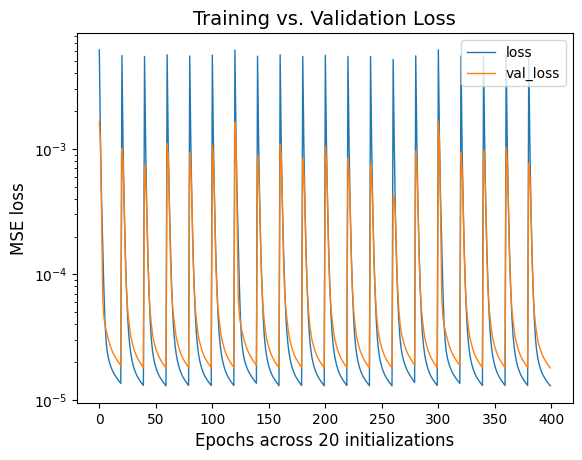

In [9]:
# Plot Accuracy Vs Lost
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
%matplotlib inline
plt.plot(loss_vector,  label='loss', lw=1)
plt.plot(val_loss_vector, label='val_loss', lw=1)
plt.yscale('log')
plt.ylabel('MSE loss', size=12)
plt.title('Training vs. Validation Loss', size=14)
plt.xlabel(f'Epochs across {NUM_RESTARTS} initializations', size=12)
plt.legend()
# plt.savefig('accuracy_cost.png')

In [10]:
# =================================================================
# Stage 2 -- BFGS fine-tuning on every Adam restart
# Runs on the full training set; for ~36 params each call is cheap.
# Best restart selected by BFGS loss (not Adam val_loss).
#
# Why CPU, not GPU:
#   Each scipy objective call does unpack->forward->backward->.numpy().
#   That is 2 GPU sync roundtrips (~1ms each) per call. 
#
# Parallelism: ThreadPoolExecutor capped at CPU core count.
# Note: tf.config.threading must be set before TF initialises (cell 0),
#       so thread limits are left at TF defaults here -- negligible cost
#       at 36 params per model.
# =================================================================
import threading, os
from scipy.optimize import minimize as scipy_minimize
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

N              = len(all_restart_weights)
N_CPU          = os.cpu_count() or 4
N_WORKERS_BFGS = min(N, N_CPU)
print(f'[BFGS] {N} restarts on CPU, {N_WORKERS_BFGS} workers ({N_CPU} cores)')

# Data on CPU
V_cpu = tf.constant(V[..., np.newaxis], dtype=tf.float32)
X_cpu = tf.constant(X[..., np.newaxis], dtype=tf.float32)

def pack_weights(model):
    return np.concatenate(
        [v.numpy().flatten() for v in model.trainable_variables]
    ).astype(np.float64)

def unpack_weights(model, flat_params):
    fp  = flat_params.astype(np.float32)
    idx = 0
    for var in model.trainable_variables:
        n = var.numpy().size
        var.assign(fp[idx:idx + n].reshape(var.shape))
        idx += n

def make_scipy_objective(model):
    @tf.function(jit_compile=False)
    def _fwd_bwd():
        with tf.GradientTape() as tape:
            pred     = model(V_cpu, training=False)
            loss_val = tf.reduce_mean(tf.square(X_cpu - pred))
        grads = tape.gradient(loss_val, model.trainable_variables)
        return loss_val, tf.concat([tf.reshape(g, [-1]) for g in grads], axis=0)

    def _fn(flat_params):
        with tf.device('/CPU:0'):
            unpack_weights(model, flat_params)
            loss, grad = _fwd_bwd()
        return float(loss.numpy()), grad.numpy().astype(np.float64)
    return _fn

# -- Pre-create one CPU model per restart 
_bfgs_models = []
for j in range(N):
    with tf.device('/CPU:0'):
        m = define_block(input_shape, BRANCH_NUMBER, LINEARIZER_ORDER,
                         k_initializer=tf.keras.initializers.Zeros(), outputs=1,
                         bias_range=BIAS_RANGE)
        m.set_weights(all_restart_weights[j])
    _bfgs_models.append(m)

# -- Pre-trace all objectives in main thread (avoids concurrent tracing) 
print('Pre-tracing BFGS functions...', end=' ', flush=True)
_bfgs_objs = []
for _j in range(N):
    _obj = make_scipy_objective(_bfgs_models[_j])
    with tf.device('/CPU:0'):
        _obj(pack_weights(_bfgs_models[_j]))   # triggers trace
    _bfgs_objs.append(_obj)
print('done.')

# -- Per-restart worker 
def _run_bfgs(j):
    model  = _bfgs_models[j]
    obj    = _bfgs_objs[j]   # pre-traced -- no tracing in threads
    x0     = pack_weights(model)
    loss_b = obj(x0)[0]
    result = scipy_minimize(obj, x0, method='BFGS', jac=True,
                            options={'maxiter': 200, 'gtol': 1e-12})
    
    # if scaling this model use L-BFGS-B instead
    # result = scipy_minimize(obj, x0, method='L-BFGS-B', jac=True,
    #                         options={'maxiter': 1000, 'ftol': 1e-15, 'gtol': 1e-12, 'maxcor': 36})
    tqdm.write(f'  Initialization {j+1:2d}  {loss_b:.2e} -> {result.fun:.2e}')
    return j, loss_b, result.fun, result.x

# -- Dispatch (always parallel) 
with ThreadPoolExecutor(max_workers=N_WORKERS_BFGS) as ex:
    raw = list(ex.map(_run_bfgs, range(N)))
raw.sort(key=lambda r: r[0])

bfgs_loss_before = [r[1] for r in raw]
bfgs_loss_after  = [r[2] for r in raw]
best_flat        = raw[int(np.argmin(bfgs_loss_after))][3]

best_bfgs_loss = min(bfgs_loss_after)
print(f'\nBest BFGS loss: {best_bfgs_loss:.2e}')

# -- Restore best weights into the final model
neural_network_model.set_weights(
    _bfgs_models[int(np.argmin(bfgs_loss_after))].get_weights()
)

X_hat      = neural_network_model.predict(V)[:, :, 0]
X_hat_test = neural_network_model.predict(V_test)[:, :, 0]
print('-' * 20 + ' Train (best BFGS) ' + '-' * 20)
compute_statistics(X, V, X_hat,
                   Q1_bits=DATA_BITS, Q2_bits=DATA_BITS, Q3_bits=EST_BITS,
                   print_on_screen=True);
print('-' * 20 + ' Test  (best BFGS) ' + '-' * 20)
compute_statistics(X_test, V_test, X_hat_test,
                   Q1_bits=DATA_BITS, Q2_bits=DATA_BITS, Q3_bits=EST_BITS,
                   print_on_screen=True);

[BFGS] 20 restarts on CPU, 4 workers (4 cores)
Pre-tracing BFGS functions... done.
  Initialization  4  1.31e-05 -> 4.26e-07
  Initialization  3  1.30e-05 -> 4.58e-07
  Initialization  1  1.36e-05 -> 4.73e-07
  Initialization  2  1.31e-05 -> 5.23e-07
  Initialization  6  1.31e-05 -> 4.55e-07
  Initialization  5  1.31e-05 -> 5.48e-07
  Initialization  8  1.31e-05 -> 5.09e-07
  Initialization  7  1.37e-05 -> 5.14e-07
  Initialization  9  1.31e-05 -> 4.15e-07
  Initialization 11  1.31e-05 -> 4.84e-07
  Initialization 10  1.30e-05 -> 4.62e-07
  Initialization 12  1.30e-05 -> 4.78e-07
  Initialization 13  1.30e-05 -> 4.56e-07
  Initialization 14  1.38e-05 -> 4.85e-07
  Initialization 15  1.31e-05 -> 5.71e-07
  Initialization 16  1.36e-05 -> 4.73e-07
  Initialization 17  1.31e-05 -> 5.52e-07
  Initialization 18  1.31e-05 -> 5.75e-07
  Initialization 20  1.30e-05 -> 4.94e-07
  Initialization 19  1.31e-05 -> 4.95e-07

Best BFGS loss: 4.15e-07
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━

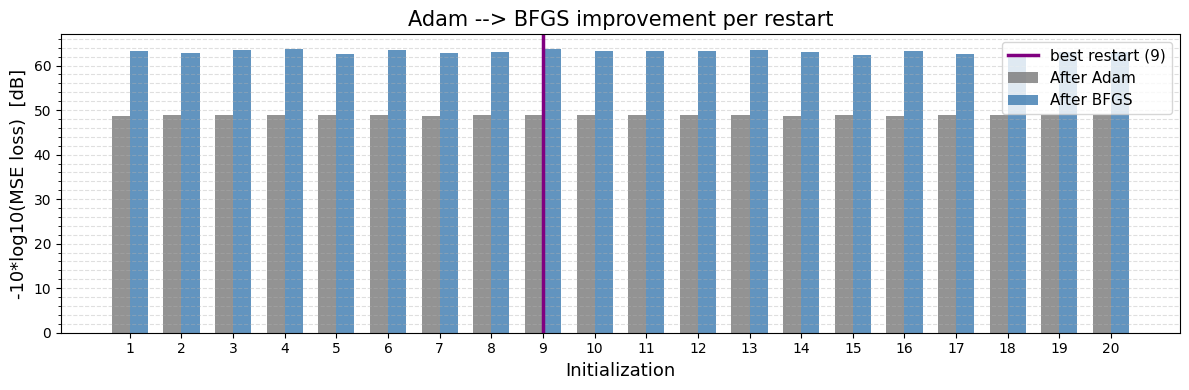

In [11]:
# =================================================================
# BFGS improvement per restart
# =================================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Convert MSE loss -> dB scale (higher = better, analogous to SNDR)
before_db = -10 * np.log10(np.array(bfgs_loss_before))
after_db  = -10 * np.log10(np.array(bfgs_loss_after))

x = np.arange(1, NUM_RESTARTS + 1)
w = 0.35
fig, ax = plt.subplots(figsize=(max(8, NUM_RESTARTS * 0.6), 4))
ax.bar(x - w/2, before_db, width=w, label='After Adam',   color='gray',  alpha=0.85)
ax.bar(x + w/2, after_db,  width=w, label='After BFGS',   color='steelblue', alpha=0.85)

best_idx = int(np.argmin(bfgs_loss_after))
ax.axvline(x[best_idx], color='purple', linestyle='-', linewidth=2.5,
           label=f'best restart ({x[best_idx]})')

ax.set_xlabel('Initialization', fontsize=13)
ax.set_ylabel('-10*log10(MSE loss)  [dB]', fontsize=13)
ax.set_title('Adam --> BFGS improvement per restart', fontsize=15)
ax.set_xticks(x)
ax.legend(fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [12]:
# =================================================================
# Inspect learned parameters
# =================================================================
# Ordered biases 
# get_weights() returns [b1, b2, b3, ..., bN], each shape (1,)
# actual bias[k] = b1 + b2 + ... + b(k+1)  (cumulative sum)
ob_weights = neural_network_model.get_layer('ordered_bias').get_weights()
bk_vals = np.array([w[0] for w in ob_weights])    # raw increments, shape (N,)
b       = np.cumsum(bk_vals)                      # actual biases, shape (N,)

# Nonlinear branch Conv1D kernels
w = []
for i in range(1, BRANCH_NUMBER + 1):
    kernel = neural_network_model.get_layer(f'conv{i}').get_weights()[0]  # (K+1,1,1)
    w.append(kernel.squeeze())
w = np.vstack(w)                                  # (BRANCH_NUMBER, kernel_size)

# Linear bypass (c0): FIR kernel  
kernel_c0, = neural_network_model.get_layer('c0').get_weights()
c0       = kernel_c0.squeeze()
# DC bias
b0 = float(neural_network_model.get_layer('output').get_weights()[0].squeeze())

print(f'Raw increments  [b1, b2, ..., bN]: {np.round(bk_vals, 5)}')
print(f'Actual biases   [cumsum]:          {np.round(b, 5)}')
print(f'\nNonlinear branch weights (rows=branches, cols=FIR taps):\n{w}')
print(f'\nLinear bypass:\n  FIR taps c0 = {c0}')
print(f'\nOutput DC offset (CustomAdd): b0 = {b0:.6f}')

Raw increments  [b1, b2, ..., bN]: [-0.78164  0.11956  0.23285  0.27632  0.2687   0.26356  0.23233  0.17618]
Actual biases   [cumsum]:          [-0.78164 -0.66208 -0.42923 -0.15291  0.11579  0.37935  0.61168  0.78786]

Nonlinear branch weights (rows=branches, cols=FIR taps):
[[-0.01725424  0.16962023 -0.03682074]
 [ 0.0088226   0.05852584 -0.03739801]
 [ 0.00361867  0.01157031 -0.01449839]
 [ 0.00831779 -0.00184403 -0.00828374]
 [ 0.0039409  -0.00775241 -0.00332038]
 [-0.00231065 -0.02284096  0.00899953]
 [-0.00089149 -0.05971333  0.00691988]
 [ 0.01644539 -0.17363754  0.06060513]]

Linear bypass:
  FIR taps c0 = [-0.01326048  0.50084317 -0.1707927 ]

Output DC offset (CustomAdd): b0 = 0.005713


In [13]:
# =================================================================
# Let's resume the stats one more time
# =================================================================
X_hat = neural_network_model.predict(V)[:,:,0]
print(np.shape(X), np.shape(V), np.shape(X_hat))
# Predicting
X_hat_test = neural_network_model.predict(V_test)[:,:,0]
neural_network_model.evaluate(V_test, X_test);
print(np.shape(X_test), np.shape(V_test), np.shape(X_hat_test))
# =================================================================
# Statistics
# =================================================================
print('-' * 20 + ' Train ' + '-' * 20)
SNR_array_X, SNR_array_V, SNR_array_X_hat = compute_statistics(
    X, V, X_hat,
    Q1_bits=DATA_BITS, Q2_bits=DATA_BITS, Q3_bits=EST_BITS,
    print_on_screen=True,
)
print('-' * 20 + ' Test  ' + '-' * 20)
SNR_X_test, SNR_V_test, SNR_X_hat_test = compute_statistics(
    X_test, V_test, X_hat_test,
    Q1_bits=DATA_BITS, Q2_bits=DATA_BITS, Q3_bits=EST_BITS,
    print_on_screen=True,
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
(50, 8192) (50, 8192) (50, 8192)
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - loss: 4.0668e-07 - mape: 1.1060
(50, 8192) (50, 8192) (50, 8192)
-------------------- Train --------------------
X:           ( 50 signals) SNDR: min: 64.96  mean: 67.14  max: 68.93
V:           ( 50 signals) SNDR: min: 28.75  mean: 30.5  max: 32.25
X_hat:    ( 50 signals) SNDR: min: 52.49  mean: 54.14 max: 55.38
-------------------- Test  --------------------
X:           ( 50 signals) SNDR: min: 64.56  mean: 67.04  max: 68.87
V:           ( 50 signals) SNDR: min: 28.65  mean: 30.54  max: 31.74
X_hat:    ( 50 signals) SNDR: min: 51.47  mean: 54.14 max: 55.11


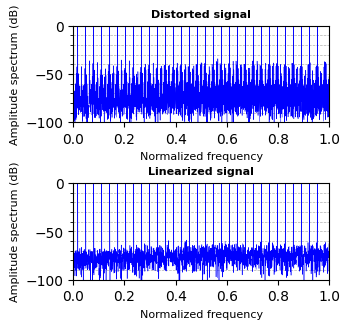

In [14]:
# =================================================================
# Plot (optional)
# =================================================================
if PLOTTING:
    title = ['Distorted signal', 'Linearized signal']
    signal_idx = 0
    SpectrumAnalyzer().plot_frequency_domain(
        [np.expand_dims(V_test[signal_idx], 0), np.expand_dims(X_hat_test[signal_idx], 0)],
        title,
        window_type='Blackmanharris',
        save_path=f"{simulation_path}/{folder_prefix}_{signal_idx}",
        save_fig=False,
    )

## Results Summary

| Signal | SNDR (test mean) | Notes |
|--------|-----------------|-------|
| Distorted V | 30.54 dB | Raw ADC output |
| CNN (adam only) | ~40 dB | 20 epochs x 20 restarts (default config) |
| **CNN (adam + BFGS)** | **54 dB** | +23 dB over distorted |
| Clean reference X | 67.04 dB | Upper bound (quantization noise floor only) |

The CNN linearizer recovers **+23 dB** over the distorted signal using only 36 trainable parameters, with no feedback path and no
look-ahead -- suitable for real-time sample-by-sample processing.

> **Note:** The distortion model is polynomial with **9 nonlinear branches + 1 linear branch**.
> The linearizer uses `BRANCH_NUMBER = 8` nonlinear branches + 1 linear bypass by default,
> with simpler activations (`abs`, `relu`) instead of exact polynomial nonlinearities -- leaving a structural mismatch.
> Increasing `BRANCH_NUMBER >= 10` and the number of initializations (`NUM_RESTARTS`) closes the remaining gap.
> Trying this is left as an exercise for the reader.